In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

In [14]:
def plot_training_curve(file_path, title, metric_name = "Accuracy", layers=None):
    df = pd.read_csv(file_path, sep="\t")
    plt.figure(figsize=(24, 6))
    for index, row in df.iterrows():
        if layers is not None and index not in layers:
            continue
        plt.plot([int(x) for x in df.columns[1:]], row[1:], label=f'Layer {index}')
        
    plt.xlabel('Step')
    plt.ylabel(metric_name)
    plt.legend()
    plt.title(title)
    
    plt.show()

In [4]:
def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", layers=None, x_max=None, normalize=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        if layers is not None and index not in layers:
            continue
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        # normalize the y_target values by the first value of y_target
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        spline = UnivariateSpline(x_target, y_target, s=0.1)
        y_smooth = spline(x_target)
        plt.plot(x_target, y_target, label=f'Layer {index} Verb Class')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]
        plt.plot(x_dependent, y_dependent, label=f'Layer {index} POS')
        #plt.plot(x_dependent, y_smooth, label=f'Layer {index+1} Dependent')        
    
    # draw a vertical line at x = 20000
    plt.axvline(x=2100, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    #plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 1000))
    plt.title(title)
    plt.legend()
    plt.show()

In [5]:
def plot_object_training_curve(target_path, dependent_path, object_path, title, metric_name = "Accuracy", layers=None, x_max=None, normalize=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    df_obj = pd.read_csv(object_path, sep="\t")
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        if layers is not None and index not in layers:
            continue
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        # normalize the y_target values by the first value of y_target
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        plt.plot(x_target, y_target, label=f'Layer {index} Verb Class Dismabiguation')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]
        plt.plot(x_dependent, y_dependent, label=f'Layer {index} Verb vs Noun Abstraction')

        x_object, y_object = [int(x) for x in df_obj.columns[1:]], df_obj.iloc[index][1:]
        if x_max is not None:
            x_object = x_object[:x_max]
            y_object = y_object[:x_max]
        if normalize:
            y_object = [(y - y_object.iloc[0]) / (y_object.iloc[-1] - y_object.iloc[0]) for y in y_object]
        plt.plot(x_object, y_object, label=f'Layer {index} Subjects vs Objects Abstraction')
    
    # draw a vertical line at x = 20000
    #plt.axvline(x=2100, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 100))
    plt.title(title)
    plt.legend()
    plt.show()

# Motion Ditransitive

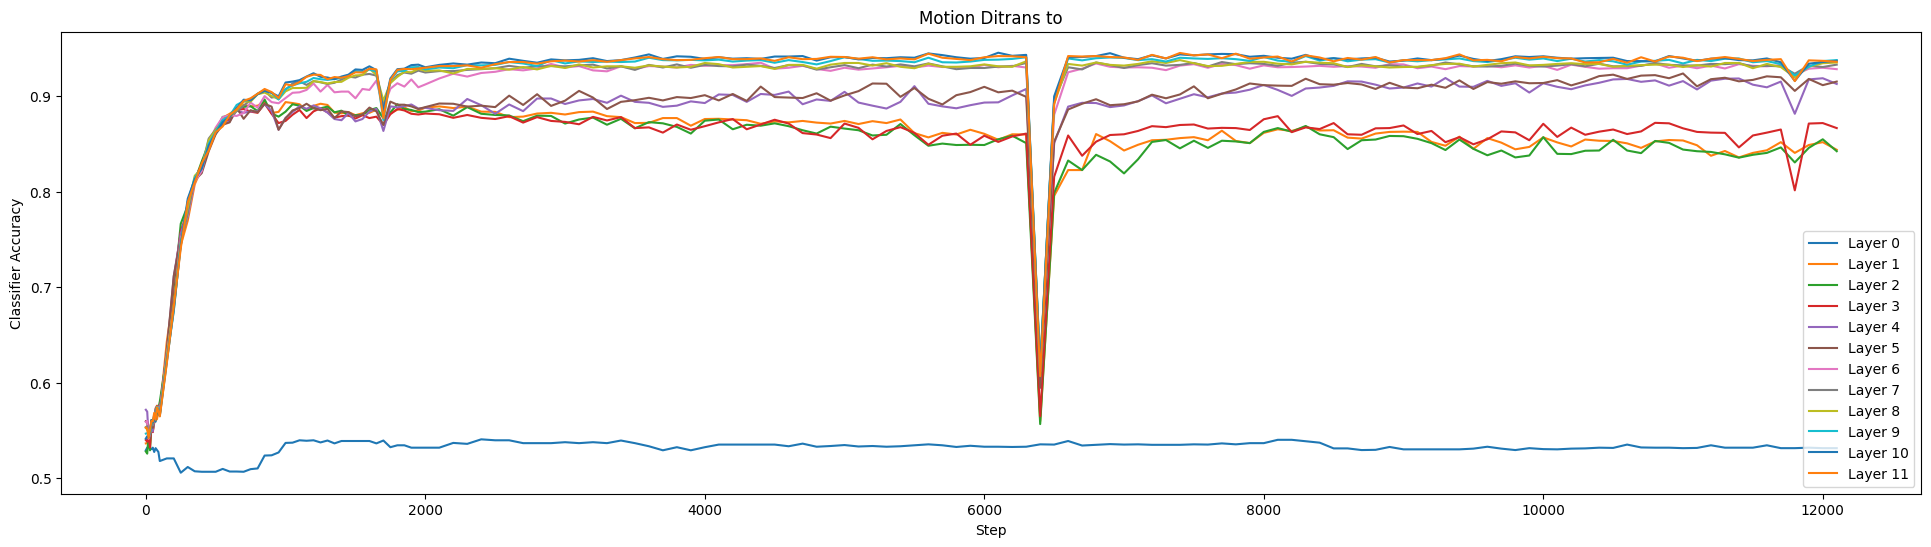

In [15]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_8/battlestar_small.ditrans_annotated.motion_annotated.target.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(12)))

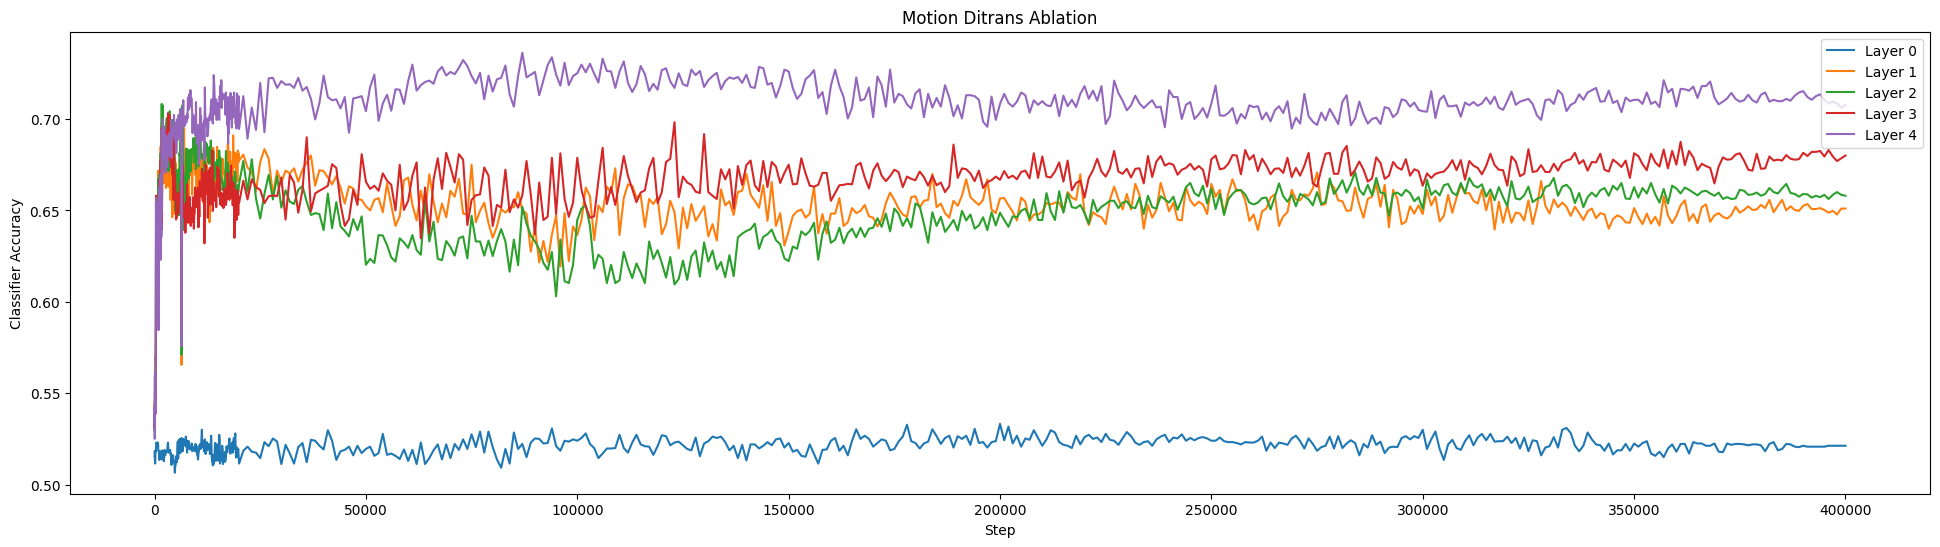

In [18]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_20.anisotropy/battlestar_small.ditrans_annotated.motion_annotated.target.tsv", "Motion Ditrans Ablation", metric_name="Classifier Accuracy", layers=list(range(0, 5)))

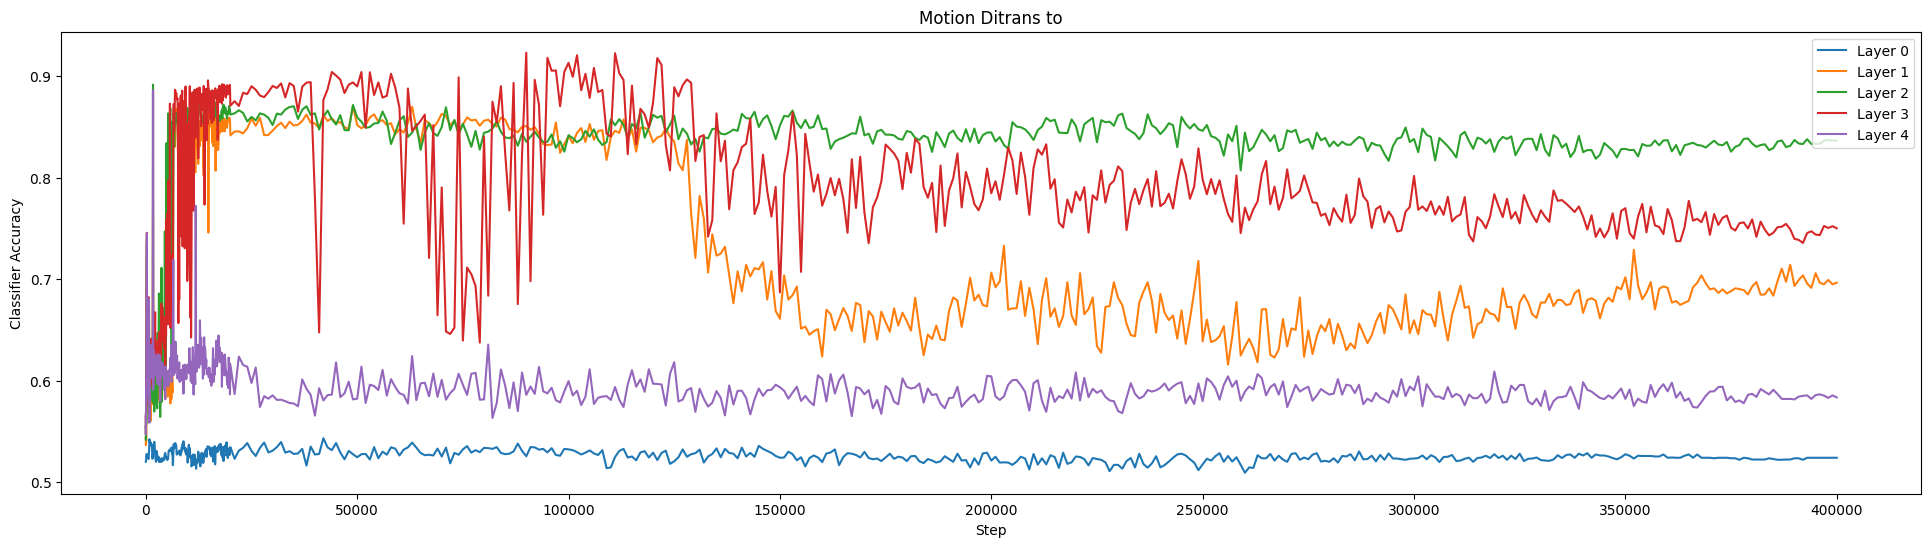

In [19]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20.anisotropy/battlestar_small.ditrans_annotated.motion_annotated.target.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(0, 5)))

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion.ditrans.dependent.tsv", "Motion Ditrans Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

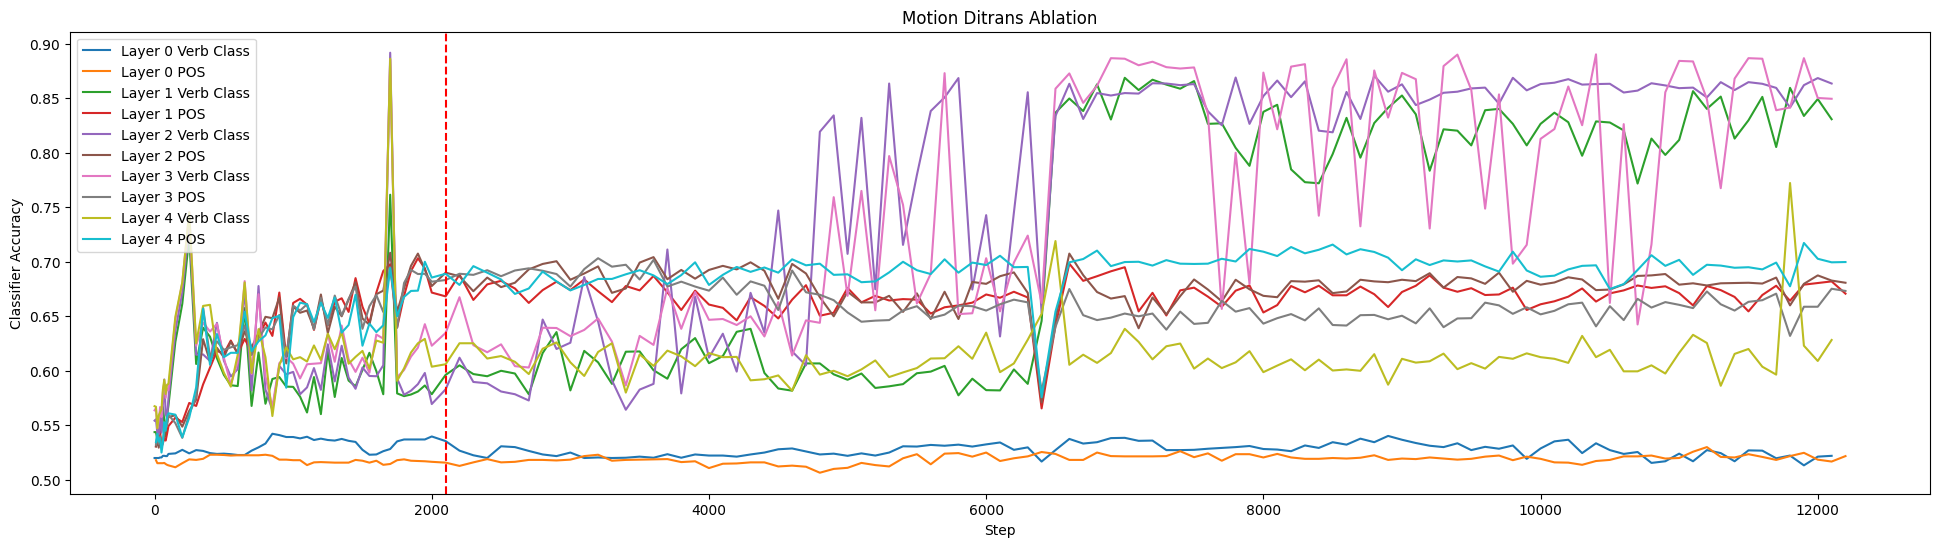

In [21]:
ablation_results = "/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_20.anisotropy/battlestar_small.ditrans_annotated.motion_annotated.target.tsv"
target_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20.anisotropy/battlestar_small.ditrans_annotated.motion_annotated.target.tsv"
plot_pair_training_curve(target_results, ablation_results, "Motion Ditrans Ablation", metric_name="Classifier Accuracy", layers=list(range(0, 5)), x_max=150)

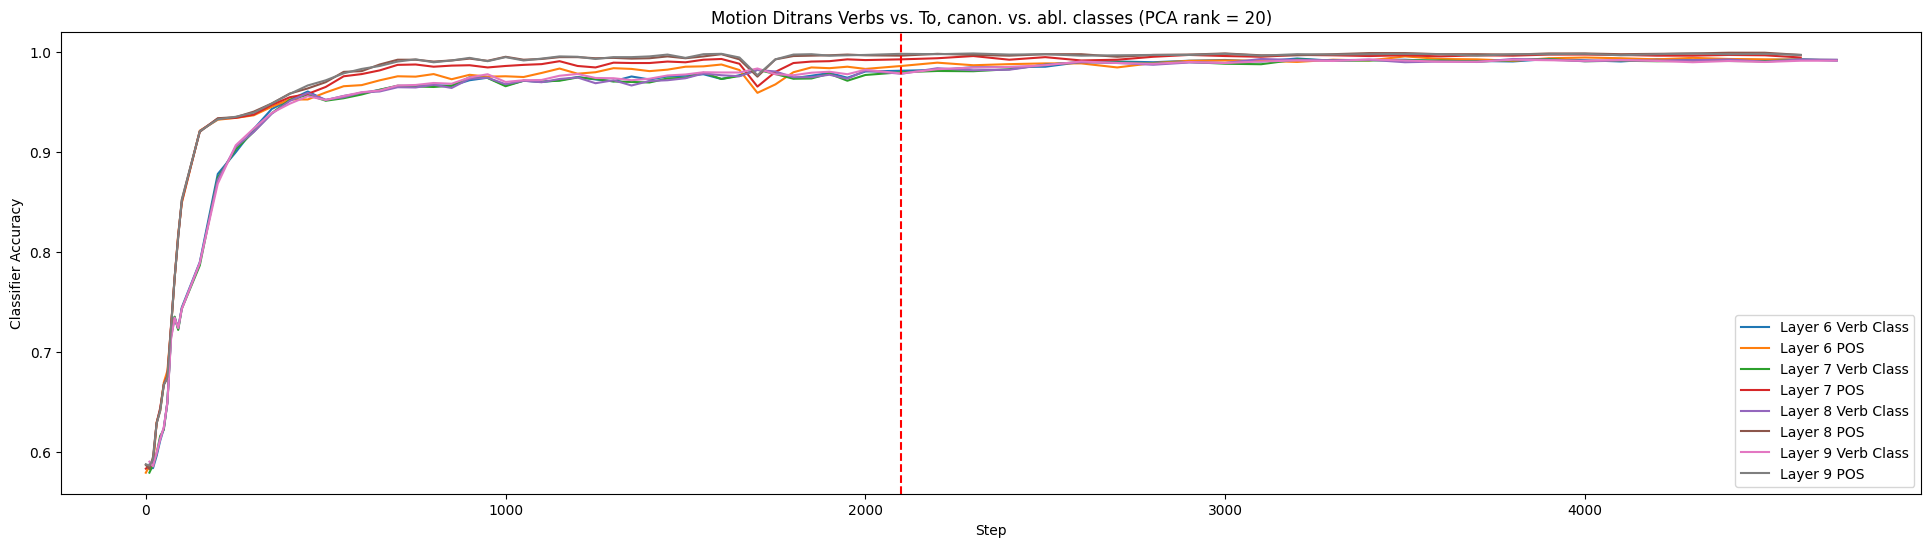

In [25]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
#verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/logistic/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/logistic/battlestar_small.ditrans_nominals.motion_balanced.ditrans_balanced.object.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_20/battlestar_small.ditrans_balanced.motion_balanced.ditrans_nominals.dependent.tsv"
plot_pair_training_curve(prep_results,verb_results, "Motion Ditrans Verbs vs. To, canon. vs. abl. classes (PCA rank = 20)", metric_name="Classifier Accuracy", layers=list(range(6, 10)), x_max=75, normalize=False)

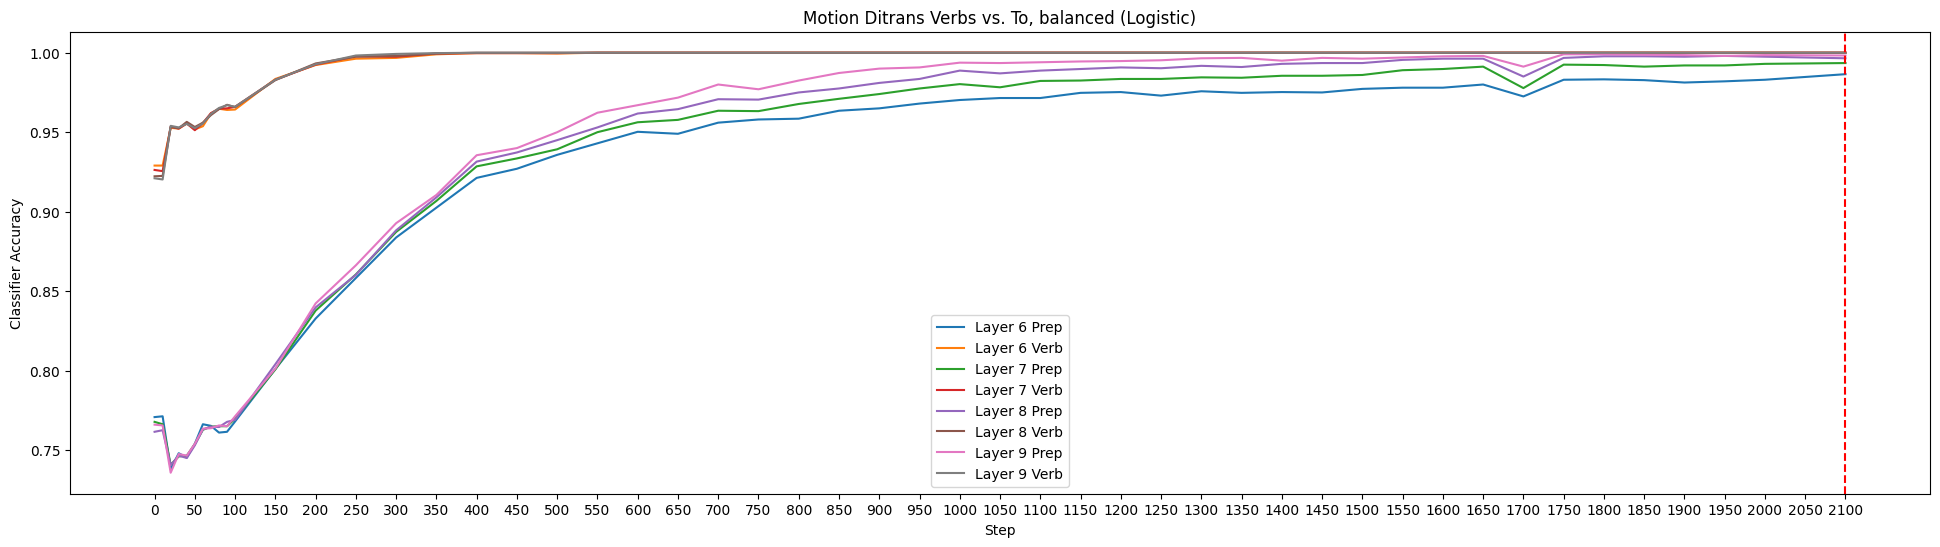

In [16]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/logistic/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/logistic/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Motion Ditrans Verbs vs. To, balanced (Logistic)", metric_name="Classifier Accuracy", layers=list(range(6, 10)), x_max=50, normalize=False)

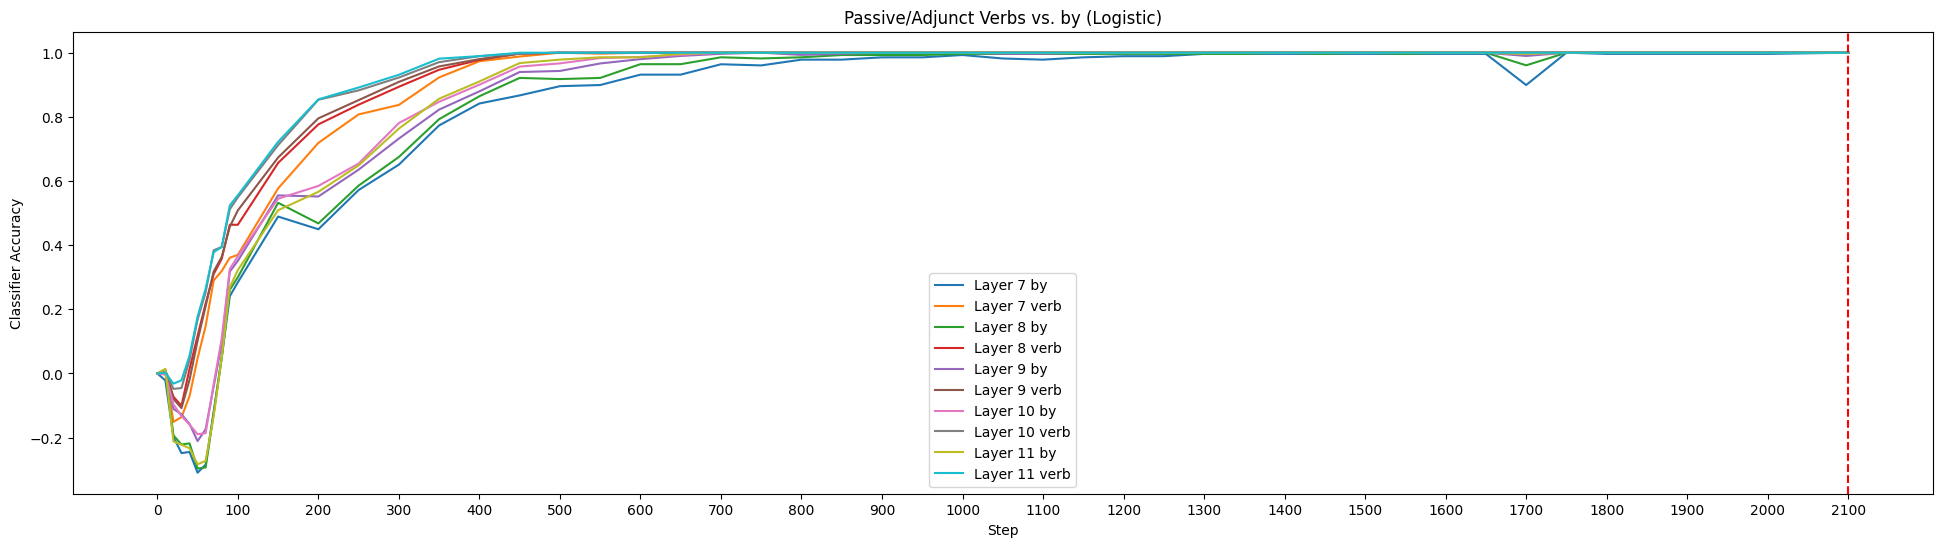

In [20]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/by/logistic/battlestar_small.by_passive.by_adjunct.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/by/logistic/battlestar_small.by_passive.by_adjunct.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Passive/Adjunct Verbs vs. by (Logistic)", metric_name="Classifier Accuracy", layers=list(range(7, 12)), x_max=50, normalize=True)

# Motion Ditransitive Balanced

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(10)))

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion_balanced.ditrans_balanced.target.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(10)))

In [ ]:
rank = 20
prep_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
verb_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
object_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_{rank}/battlestar_small.ditrans_balanced.motion_balanced.ditrans_nominals.dependent.tsv"

plot_object_training_curve(prep_results,verb_results,object_results, f"Motion Ditrans Verbs vs. To (PCA Rank = {rank})", metric_name="Classifier Accuracy", layers=list(range(8, 10)), x_max=75, normalize=True)


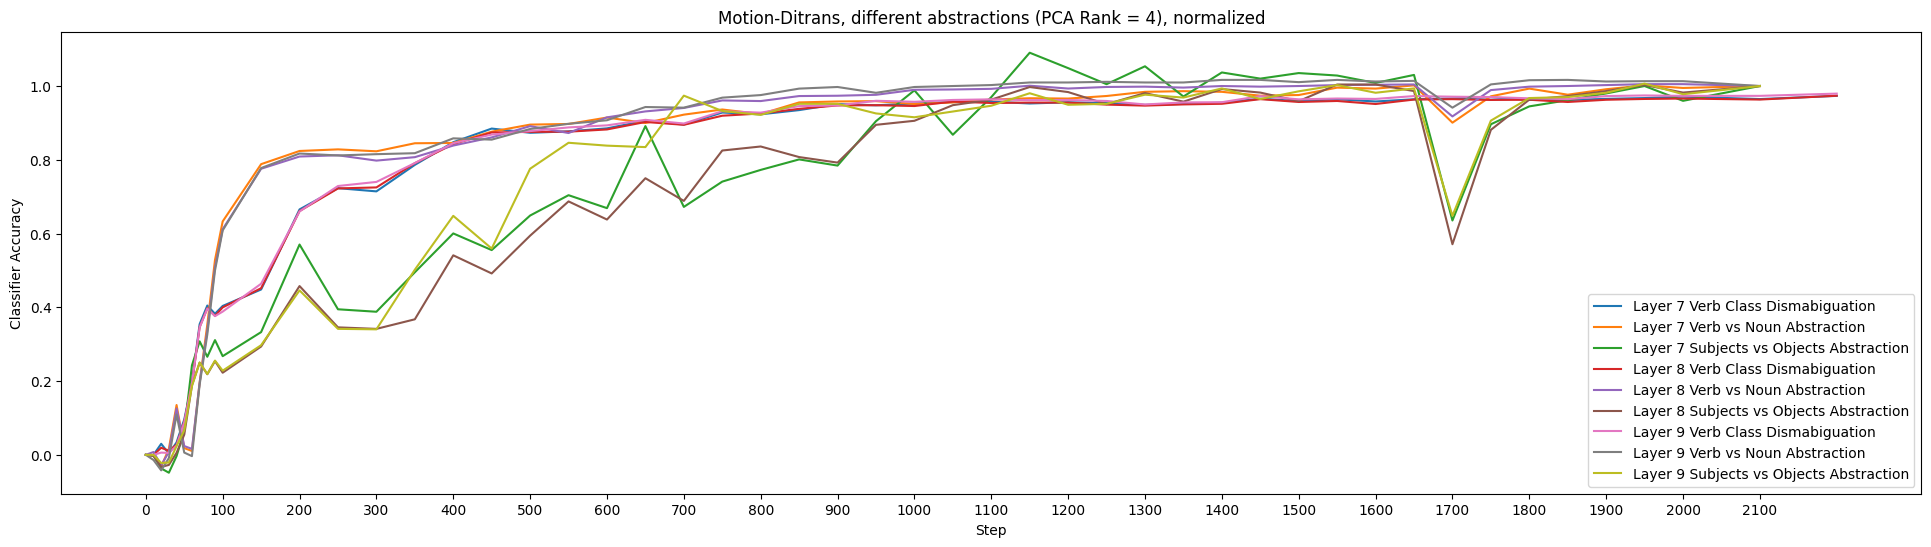

In [89]:
rank = 4

verb_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
object_vs_verb = f"/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_{rank}/battlestar_small.ditrans_balanced.motion_balanced.ditrans_nominals.dependent.tsv"
subject_vs_object = f"/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_{rank}/battlestar_small.ditrans_nominals.ditrans_nominals.subject.tsv"

plot_object_training_curve(verb_results,object_vs_verb,subject_vs_object, f"Motion-Ditrans, different abstractions (PCA Rank = {rank}), normalized", metric_name="Classifier Accuracy", layers=list(range(7, 10)), x_max=50, normalize=True)

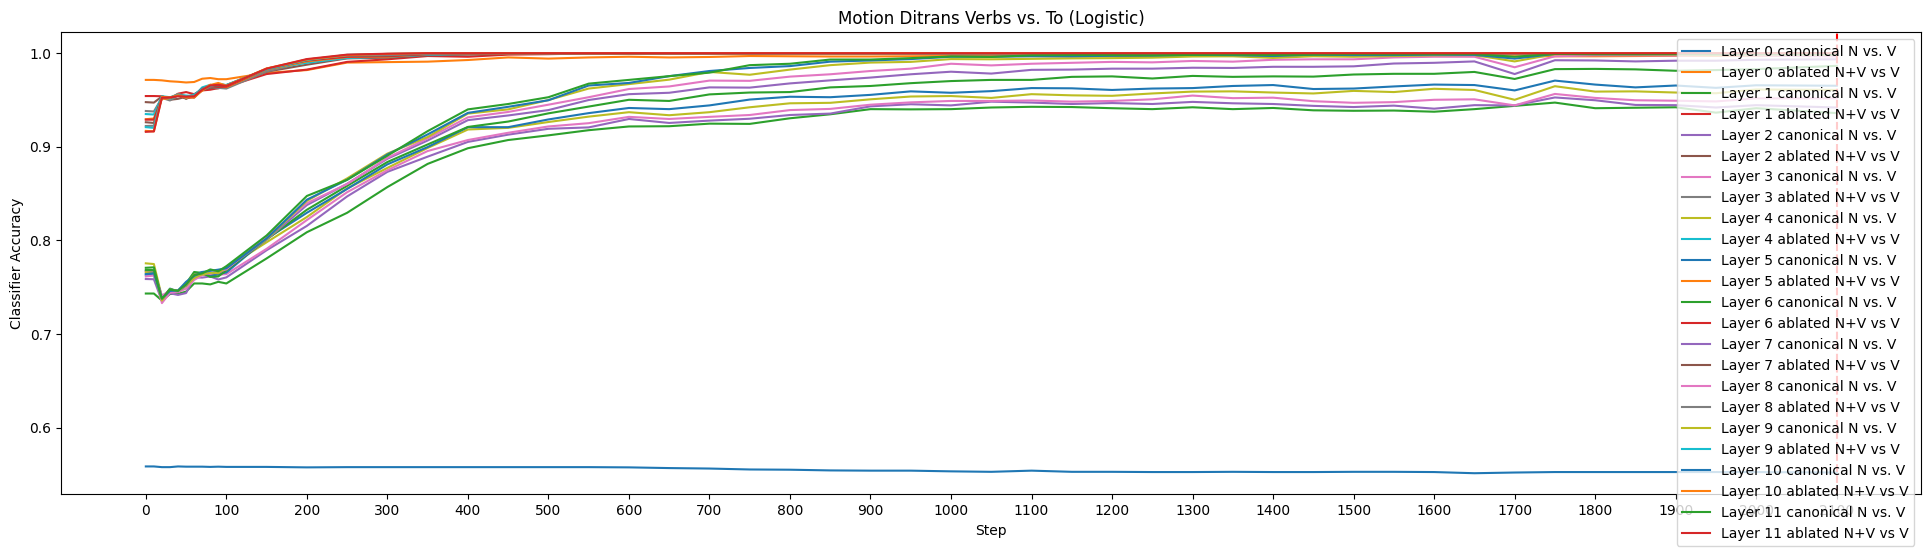

In [8]:
verb_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/logistic/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
prep_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/logistic/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
object_results = "/sailhome/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_20/battlestar_small.ditrans_nominals.ditrans_nominals.subject.tsv"

plot_pair_training_curve(prep_results,verb_results, f"Motion Ditrans Verbs vs. To (Logistic)", metric_name="Classifier Accuracy", layers=list(range(0, 12)), x_max=50, normalize=False)


# Ablation for motion and ditransitive abstractions

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_8/battlestar_small.motion_balanced.ditrans_balanced.target.tsv", "Ablation to", metric_name="Classifier Accuracy", layers=list(range(10)))

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_8/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv", "Ablation Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

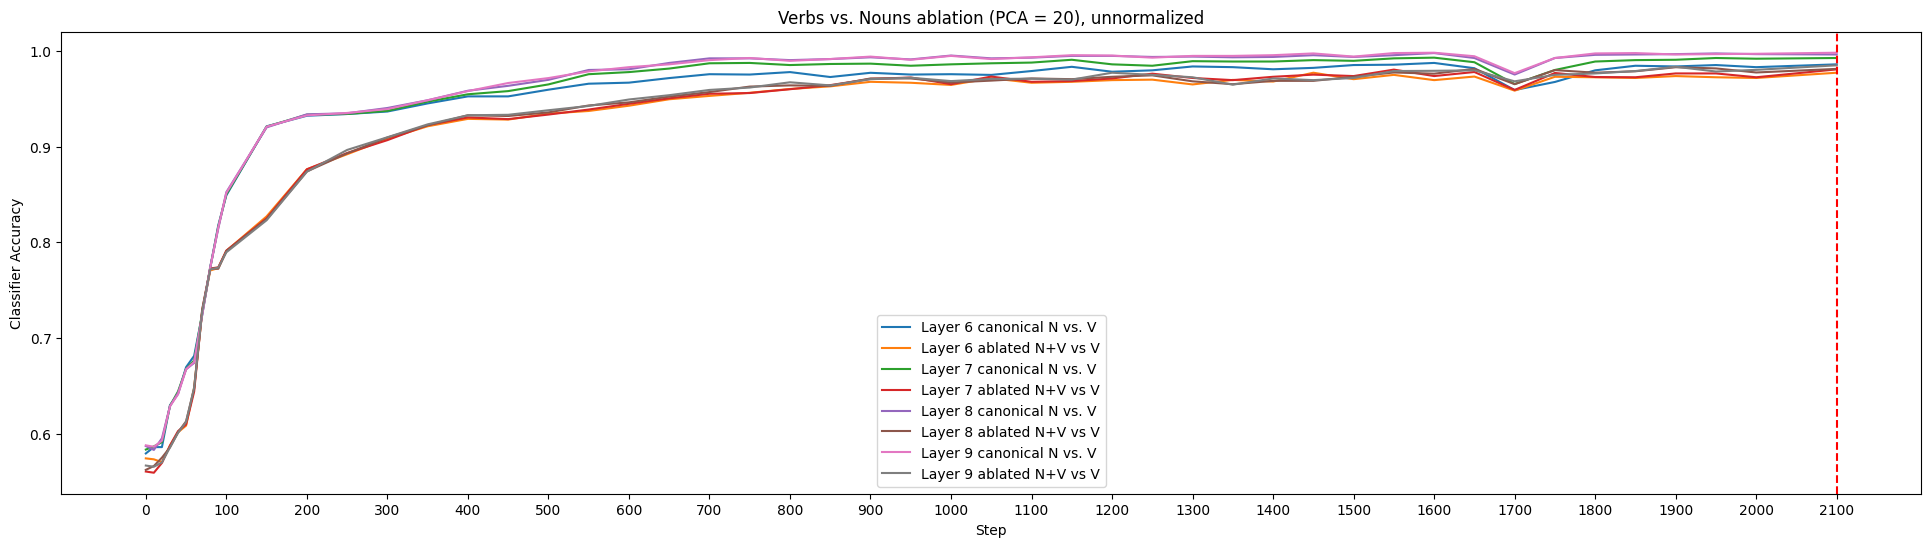

In [52]:
rank = 20
prep_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_{rank}/battlestar_small.ditrans_balanced.motion_balanced.ditrans_nominals.dependent.tsv"
verb_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/ditrans_nominals/pca_{rank}/battlestar_small.ditrans_nominals.motion_balanced.ditrans_balanced.object.tsv"

plot_pair_training_curve(prep_results,verb_results, f"Verbs vs. Nouns ablation (PCA = {rank}), unnormalized", metric_name="Classifier Accuracy", layers=list(range(6, 10)), x_max=50, normalize=False)

# With

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.dependent.tsv", "Substance Other Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

In [ ]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.target.tsv", "Substance Adjunct with", metric_name="Classifier Accuracy", layers=list(range(10)))

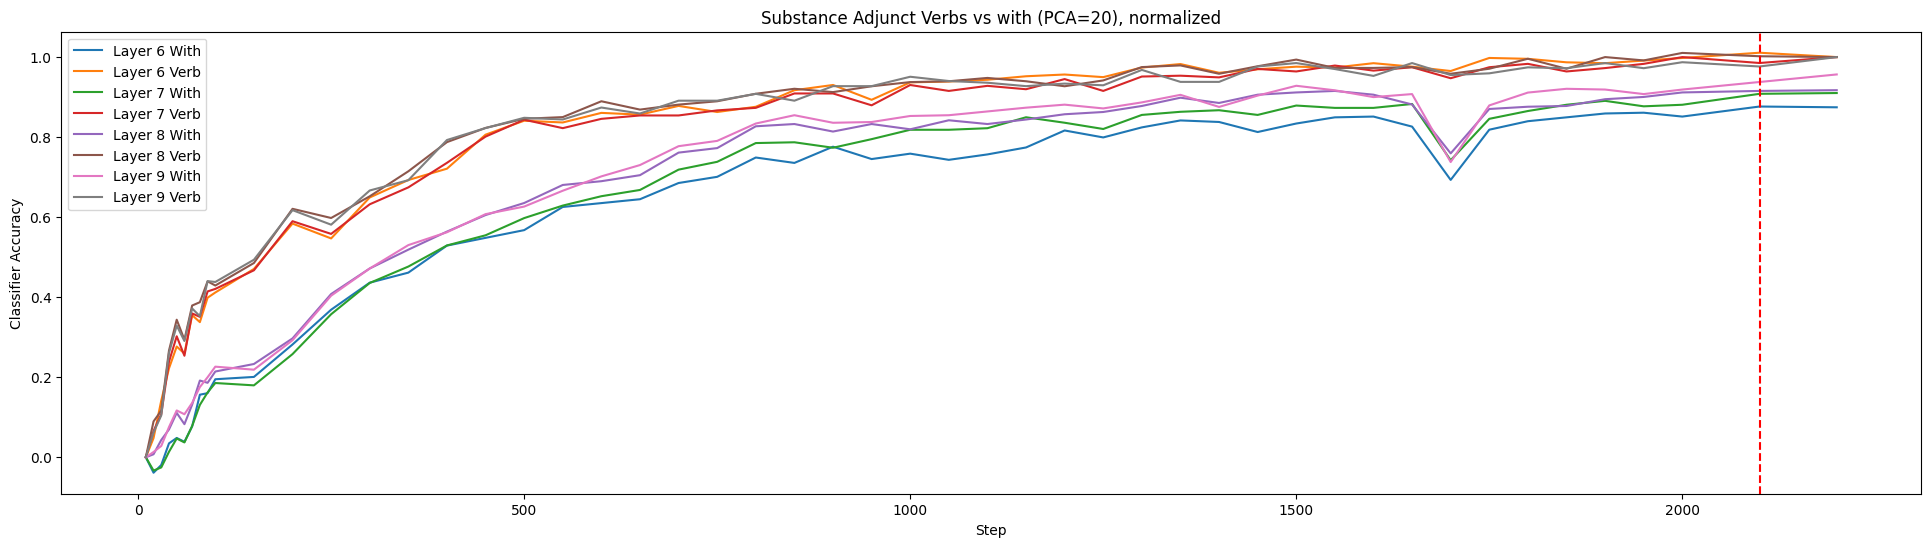

In [40]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Substance Adjunct Verbs vs with (PCA=20), normalized", metric_name="Classifier Accuracy", layers=list(range(6, 10)), x_max=50, normalize=True)

# Passive Adjunct

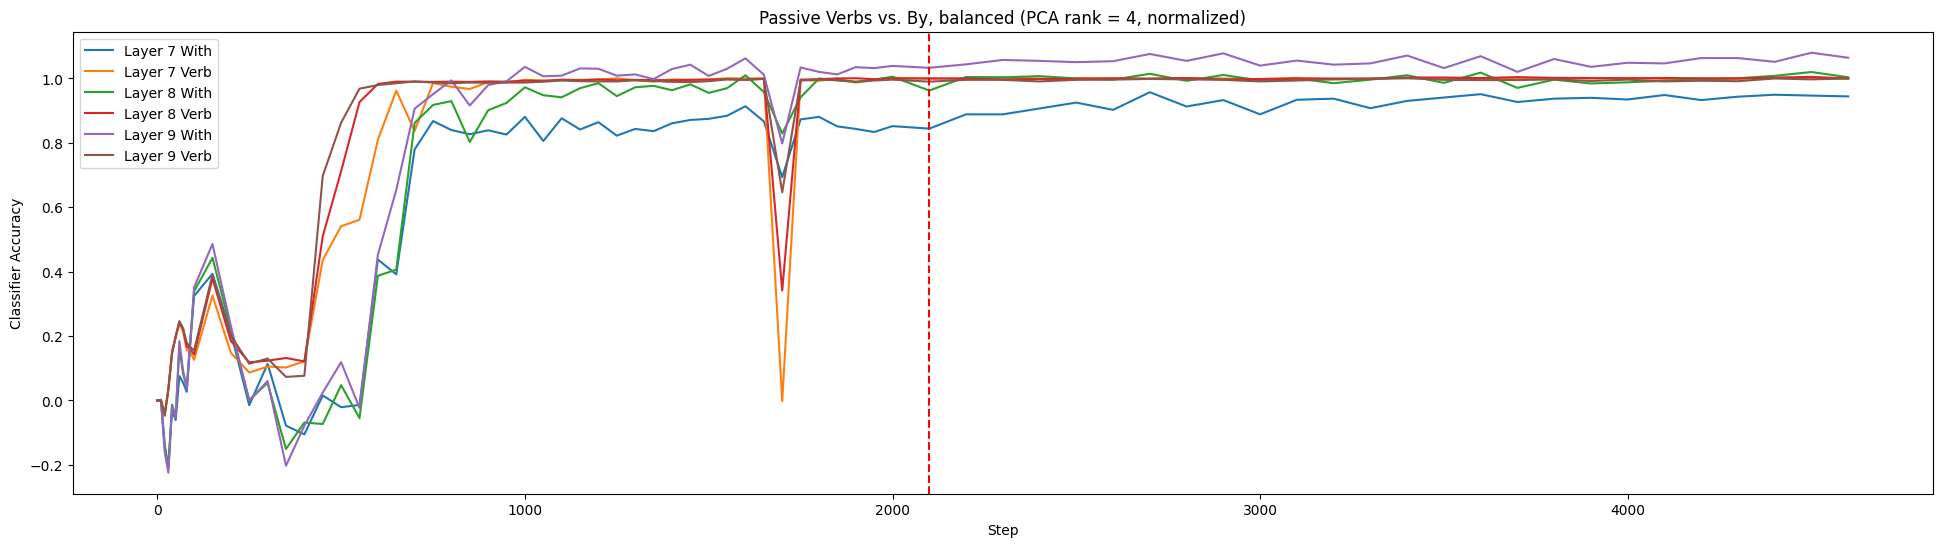

In [56]:
pca=4
prep_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/by/pca_{pca}/battlestar_small.by_passive.by_adjunct.target.tsv"
verb_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/by/pca_{pca}/battlestar_small.by_passive.by_adjunct.dependent.tsv"

plot_pair_training_curve(prep_results, verb_results, f"Passive Verbs vs. By, balanced (PCA rank = {pca}, normalized)", metric_name="Classifier Accuracy", layers=list(range(7, 10)), x_max=75, normalize=True)

In [ ]:
prep_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/by/logistic/battlestar_small.by_passive.by_adjunct.target.tsv"
verb_results = f"/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/wikitext/by/logistic/battlestar_small.by_passive.by_adjunct.dependent.tsv"

plot_pair_training_curve(prep_results, verb_results, f"Passive Verbs vs. By, balanced (Logistic)", metric_name="Classifier Accuracy", layers=list(range(8, 12)), x_max=50, normalize=False)

# Train - Test Split Ablation

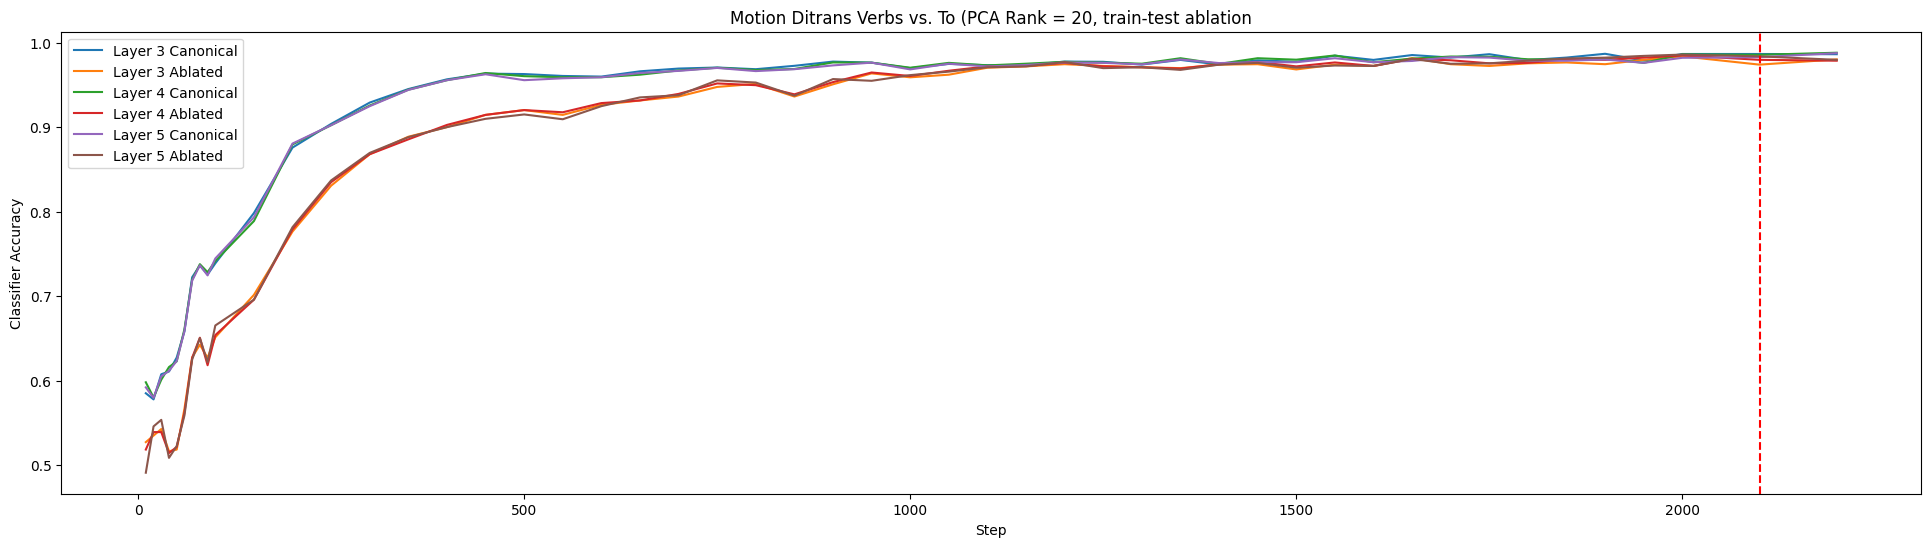

In [37]:
rank = 20

verb_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
prep_results = f"/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
train_test_results = f"/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/train_test_ablation/pca_{rank}/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
prep_results = train_test_results
plot_pair_training_curve(verb_results,train_test_results, f"Motion Ditrans Verbs vs. To (PCA Rank = {rank}, train-test ablation", metric_name="Classifier Accuracy", layers=list(range(3, 6)), x_max=50, normalize=False)
